# Data Exploration: ERCOT Load and Renewable Output

This notebook scans raw ERCOT Excel files, profiles columns, builds a cleaned hourly dataset, and visualizes key trends.

In [36]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)

# Set up paths for raw data (original data directly from sources) and processed data (cleaned and transformed data ready for analysis)
ROOT = Path("C:/Renewable-PowerGrid-Risk")
RAW_DIR = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

all_files = sorted(RAW_DIR.glob('*.xlsx'))

load_files = [f for f in all_files if 'Native_Load' in f.name]
renewable_files = [f for f in all_files if 'WindSolar' in f.name]

print(load_files, renewable_files)

for f in all_files:
    print('-', f.name)

print(len(load_files),len(renewable_files))


[WindowsPath('C:/Renewable-PowerGrid-Risk/data/raw/Native_Load_2022.xlsx'), WindowsPath('C:/Renewable-PowerGrid-Risk/data/raw/Native_Load_2023.xlsx'), WindowsPath('C:/Renewable-PowerGrid-Risk/data/raw/Native_Load_2024.xlsx'), WindowsPath('C:/Renewable-PowerGrid-Risk/data/raw/Native_Load_2025.xlsx')] [WindowsPath('C:/Renewable-PowerGrid-Risk/data/raw/ERCOT_2023_Hourly_WindSolar_Output.xlsx'), WindowsPath('C:/Renewable-PowerGrid-Risk/data/raw/ERCOT_2024_Hourly_WindSolar_Output.xlsx'), WindowsPath('C:/Renewable-PowerGrid-Risk/data/raw/ERCOT_2025_Hourly_WindSolar_Output.xlsx')]
- ERCOT_2023_Hourly_WindSolar_Output.xlsx
- ERCOT_2024_Hourly_WindSolar_Output.xlsx
- ERCOT_2025_Hourly_WindSolar_Output.xlsx
- Native_Load_2022.xlsx
- Native_Load_2023.xlsx
- Native_Load_2024.xlsx
- Native_Load_2025.xlsx
4 3


In [37]:
# Since ERCOT.LOAD is already included in renewable files, we can skip loading load files separately
#load_frames = [pd.read_excel(f) for f in load_files]
wind_frames = [pd.read_excel(f, sheet_name='Wind Data') for f in renewable_files]
solar_frames = [pd.read_excel(f, sheet_name='Solar Data') for f in renewable_files]

#load_df = pd.concat(load_frames, ignore_index=True) 
wind_df = pd.concat(wind_frames, ignore_index=True) 
solar_df = pd.concat(solar_frames, ignore_index=True) 

#print('Load rows:', len(load_df))
print('Wind rows:', len(wind_df))
print('Solar rows:', len(solar_df))
#display(load_df.head(3))
display(wind_df.head(3))
display(solar_df.head(3))

wind_df.rename(columns={'Time (Hour-Ending)':'datetime'}, inplace=True) 
solar_df.rename(columns={'Time (Hour-Ending)':'datetime'}, inplace=True) 

df=wind_df.merge(solar_df.drop(columns=['ERCOT.LOAD']), on=['Date','datetime'], how='outer')

print(df.head(3))

Wind rows: 26304
Solar rows: 26304


,Time (Hour-Ending),Date,ERCOT.LOAD,ERCOT.WIND.GEN,"Total Wind Installed, MW","Wind Output, % of Load","Wind Output, % of Installed",Wind 1-hr MW change,Wind 1-hr % change
0,2023-01-01 01:00:00,2023-01-01,35829.306163,21753.284477,36858,60.713664,59.019167,NaN,NaN
1,2023-01-01 02:00:00,2023-01-01,35245.390234,21570.395694,36858,61.200615,58.522968,-182.888783,-0.840741
2,2023-01-01 03:00:00,2023-01-01,34599.761810,21036.504013,36858,60.799563,57.074459,-533.891682,-2.475113


,Time (Hour-Ending),Date,ERCOT.LOAD,ERCOT.PVGR.GEN,"Total Solar Installed, MW","Solar Output, % of Load","Solar Output, % of Installed",Solar 1-hr MW change,Solar 1-hr % change,Daytime Hour,Ramping Daytime Hour
0,2023-01-01 01:00:00,2023-01-01,35829.306163,0.449746,14249,0.001255,0.003156,NaN,NaN,False,False
1,2023-01-01 02:00:00,2023-01-01,35245.390234,0.454733,14249,0.001290,0.003191,0.0,0.0,False,False
2,2023-01-01 03:00:00,2023-01-01,34599.761810,0.443528,14249,0.001282,0.003113,0.0,0.0,False,False


             datetime       Date    ERCOT.LOAD  ERCOT.WIND.GEN  Total Wind Installed, MW  Wind Output, % of Load  \
0 2023-01-01 01:00:00 2023-01-01  35829.306163    21753.284477                     36858               60.713664   
1 2023-01-01 02:00:00 2023-01-01  35245.390234    21570.395694                     36858               61.200615   
2 2023-01-01 03:00:00 2023-01-01  34599.761810    21036.504013                     36858               60.799563   

   Wind Output, % of Installed  Wind 1-hr MW change  Wind 1-hr % change  ERCOT.PVGR.GEN  Total Solar Installed, MW  \
0                    59.019167                  NaN                 NaN        0.449746                      14249   
1                    58.522968          -182.888783           -0.840741        0.454733                      14249   
2                    57.074459          -533.891682           -2.475113        0.443528                      14249   

   Solar Output, % of Load  Solar Output, % of Installed  Sola

             datetime       Date    ERCOT.LOAD  ERCOT.WIND.GEN  Total Wind Installed, MW  Wind Output, % of Load  \
0 2023-01-01 01:00:00 2023-01-01  35829.306163    21753.284477                     36858               60.713664   
1 2023-01-01 02:00:00 2023-01-01  35245.390234    21570.395694                     36858               61.200615   
2 2023-01-01 03:00:00 2023-01-01  34599.761810    21036.504013                     36858               60.799563   

   Wind Output, % of Installed  Wind 1-hr MW change  Wind 1-hr % change  ERCOT.PVGR.GEN  Total Solar Installed, MW  \
0                    59.019167                  NaN                 NaN        0.449746                      14249   
1                    58.522968          -182.888783           -0.840741        0.454733                      14249   
2                    57.074459          -533.891682           -2.475113        0.443528                      14249   

   Solar Output, % of Load  Solar Output, % of Installed  Sola

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
datetime,26310,NaN,NaN,NaN,2024-07-02 01:49:47.958950912,2023-01-01 01:00:00,2023-10-02 03:15:00,2024-07-02 02:30:00,2025-04-02 01:45:00,2026-01-01 00:00:00,NaN
Date,26310,NaN,NaN,NaN,2024-07-01 14:19:56.989737472,2023-01-01 00:00:00,2023-10-02 00:00:00,2024-07-02 00:00:00,2025-04-02 00:00:00,2026-01-01 00:00:00,NaN
ERCOT.LOAD,26310.0,NaN,NaN,NaN,53438.929965,33681.54079,45135.798407,50770.917575,59905.198341,85544.435964,11034.873638
ERCOT.WIND.GEN,26310.0,NaN,NaN,NaN,12722.43934,37.929258,6985.579279,12331.829213,18338.158423,28264.502331,6697.104445
"Total Wind Installed, MW",26310.0,NaN,NaN,NaN,38967.343444,36858.0,37697.0,39357.0,39618.0,40646.0,1034.734982
"Wind Output, % of Load",26310.0,NaN,NaN,NaN,25.163183,0.078255,12.727139,22.996874,35.997287,68.368543,14.910273
"Wind Output, % of Installed",26310.0,NaN,NaN,NaN,32.671512,0.100648,17.897354,31.710093,47.111174,71.342577,17.207458
Wind 1-hr MW change,26307.0,NaN,NaN,NaN,-0.129523,-6521.176387,-737.532272,-39.145314,701.021503,6057.501772,1263.749539
Wind 1-hr % change,26307.0,NaN,NaN,NaN,1.116068,-77.787007,-6.536035,-0.30406,6.990234,427.579231,15.668997
ERCOT.PVGR.GEN,26310.0,NaN,NaN,NaN,5592.289546,0.00001,0.407011,333.465585,10690.622096,29503.086634,7433.09054


Saved merged dataset to: C:\Renewable-PowerGrid-Risk\data\processed\hourly_load_renewable_merged.csv


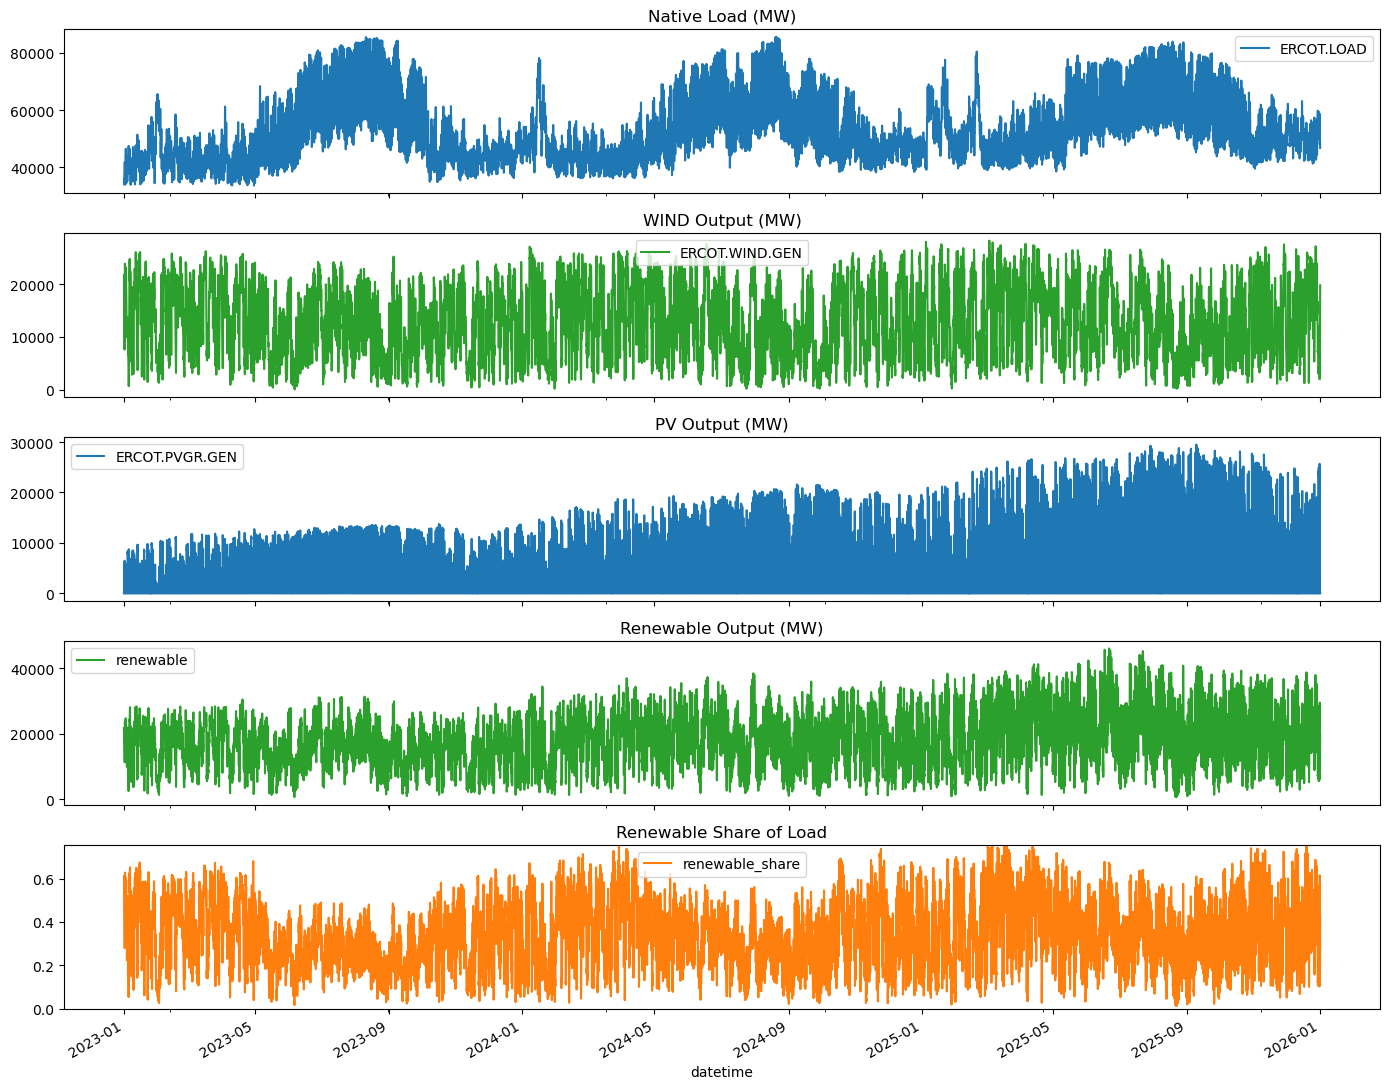

In [44]:

df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month
df['renewable']= (df['ERCOT.WIND.GEN'] + df['ERCOT.PVGR.GEN']) 
df['renewable_share'] = df['renewable'] / df['ERCOT.LOAD']

display(df.describe(include='all', datetime_is_numeric=True).T)

fig, axes = plt.subplots(5, 1, figsize=(14, 11), sharex=True)
df.plot(x='datetime', y='ERCOT.LOAD', ax=axes[0], title='Native Load (MW)')
df.plot(x='datetime', y='ERCOT.WIND.GEN', ax=axes[1], title='WIND Output (MW)', color='tab:green')
df.plot(x='datetime', y='ERCOT.PVGR.GEN', ax=axes[2], title='PV Output (MW)', color='tab:blue')
df.plot(x='datetime', y='renewable', ax=axes[3], title='Renewable Output (MW)', color='tab:green')
df.plot(x='datetime', y='renewable_share', ax=axes[4], title='Renewable Share of Load', color='tab:orange')
axes[4].set_ylim(0, min(1.2, np.nanmax(df['renewable_share']) if len(df) else 1.0))
plt.tight_layout()

out_path = PROCESSED_DIR / 'hourly_load_renewable_merged.csv'
df.to_csv(out_path, index=False)
print('Saved merged dataset to:', out_path)

## Next Steps
1. Add anomaly labels (for example, top 1% load spikes and large residual changes).
2. Engineer lag and rolling-window features for model training in `src/`.
3. Compare seasonal patterns by year and month for grid-risk interpretation.